# **Facial Emotion Detection**

## **Problem Definition**

**The context:** Why is this problem important to solve?<br>
**Human-Computer Interaction (HCI)**: Improving the way computers
understand human emotions can enhance user experiences in applications such as virtual assistants, educational software, and customer service bots.

**Mental Health Monitoring**: Automated emotional recognition can be used in telehealth to assess patients' emotional states over time, providing valuable data for psychological analysis and therapy.

**Security and Surveillance**: Emotional recognition can add an additional layer of security where understanding emotional states is crucial, such as monitoring stress levels in high-security environments.

**Marketing and Retail**: Understanding customer emotions can help businesses tailor marketing strategies and improve customer service by adjusting interactions based on the customer's current mood.

**The objectives:** What is the intended goal?
Create a convolutional neural network (CNN) and transfer learning networks that accurately identifies and classifies different facial expressions into categories like happy, sad, neutral, and surprise.

**The key questions:** What are the key questions that need to be answered?<br>
Do we have enough data to train the model effectively? Is the data accurately labeled and representative of the diverse populations that the model will serve?

**The problem formulation:** What are we trying to solve using data science?
**Objective**: To develop a data-driven model using convolutional neural networks that can accurately classify facial expressions into predefined emotional states.

**Inputs**: Images containing human faces.
**Outputs**: Class labels (happy, sad, neutral, surprise) for each detected face, possibly with a confidence score.
**Method**: Utilize deep learning techniques, CNNs and pre-trained models (VGG16, RestNET), to extract features from facial images that are indicative of emotional states and classify these features into the target categories.
**Evaluation**: Measure the performance of the model using metrics such as accuracy, precision, recall, and F1-score.



## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [1]:
# connecting Google Drive to this Python notebook
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importing the Libraries**

In [2]:
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import tensorflow as tf
import keras

# Importing Deep Learning Libraries

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, GlobalAveragePooling2D, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D, LeakyReLU
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

### **Let us load and unzip the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

In [3]:
# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/capstone_project_files/Facial_emotion_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

In [4]:
picture_size = 48
folder_path = "Facial_emotion_images/"

## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

### **Happy**

**Observations and Insights: Happy**

Smile: The presence of a smile, characterized by the upward movement of the mouth corners and the exposure of teeth, is the most distinctive feature.

Eye Wrinkles: Often, smiling causes crow's feet or wrinkles to appear at the outer corners of the eyes.

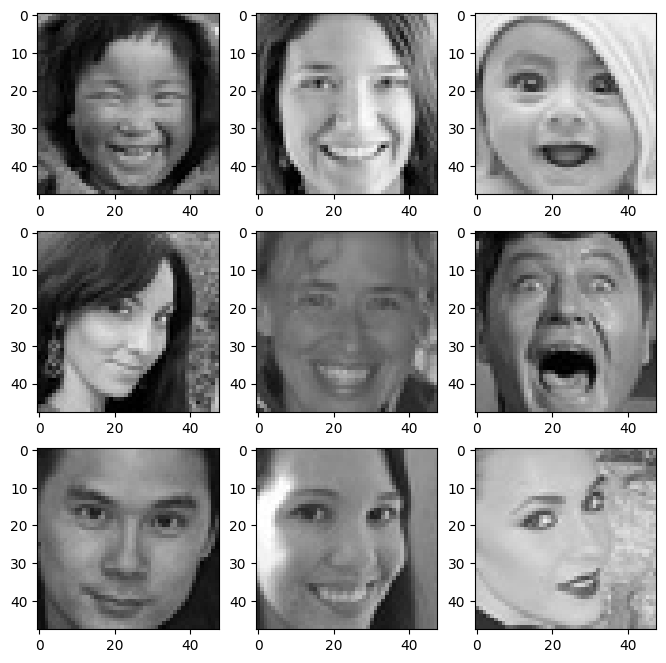

In [ ]:
expression = 'happy'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

### **Sad**

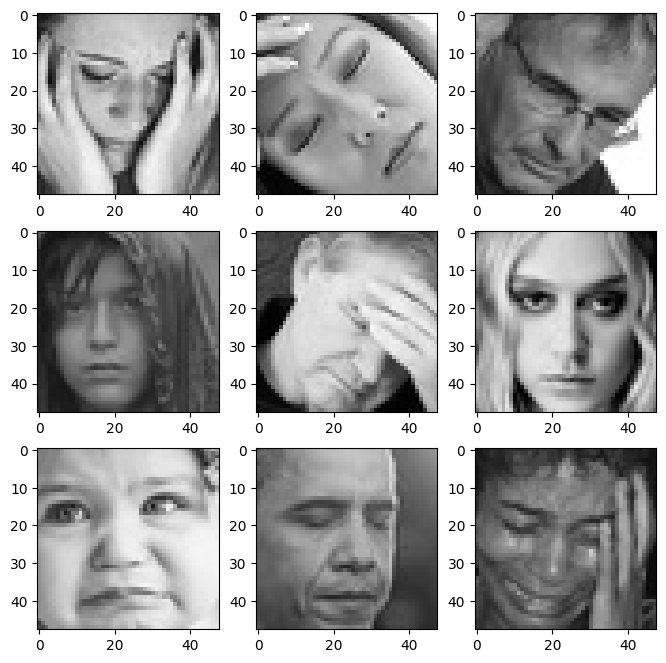

In [ ]:
expression = 'sad'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:Sad**

Frowning: The eyebrows are drawn together, and the forehead is often wrinkled.

Downturned Mouth: The corners of the mouth are turned downward, unlike in a smile.

Lack of Eye Sparkle: The eyes may appear dull or slightly teary, lacking the brightness seen in happier expressions.

### **Neutral**

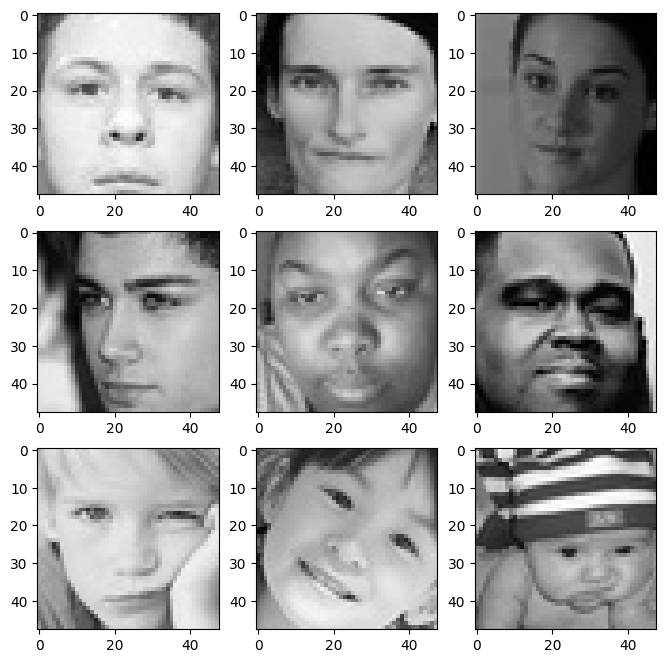

In [ ]:
expression = 'neutral'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:Neutral**

Relaxed Features: There is an absence of significant muscle tension around the forehead, eyes, and mouth.

Closed Lips: The mouth is usually closed and not curved or downturned.

Neutral Eyes: The eyes do not show particular engagement or disengagement, often making this expression harder to detect with high confidence compared to more expressive states.

### **Surprised**

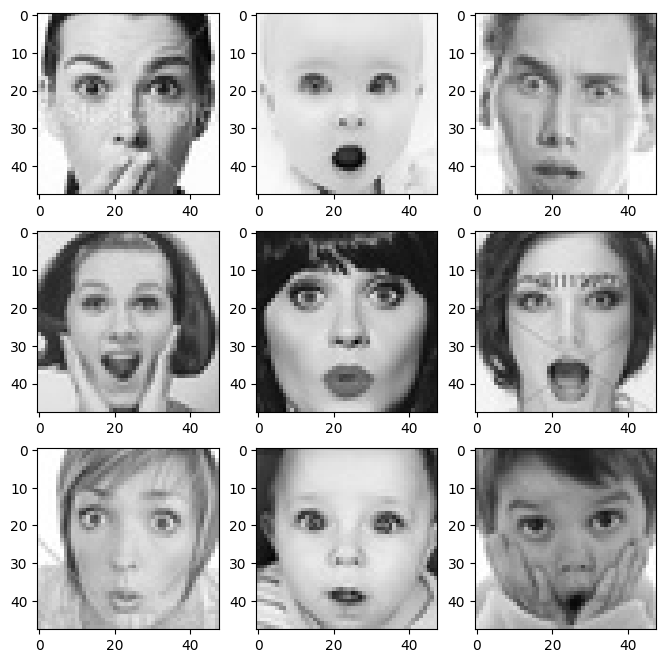

In [ ]:
expression = 'surprise'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights: Surprise**

Raised Eyebrows: One of the most noticeable features is the arching of eyebrows, creating a curved and high position.

Wide Eyes: The eyes are opened wider than usual, increasing visibility of the whites of the eyes.

Open Mouth: Often, the mouth is open without tension, different from an expression of fear where the mouth might also be open but with a tensed jaw.

## **Checking Distribution of Classes**

In [ ]:
# Count images in each folder within our training path
num_happy = len(os.listdir(folder_path + "train/happy"))
print("Number of images in the class 'happy':   ", num_happy)

Number of images in the class 'happy':    3976


In [ ]:
num_sad = len(os.listdir(folder_path + "train/sad"))
print("Number of images in the class 'sad':   ", num_sad)

Number of images in the class 'sad':    3982


In [ ]:
num_neutral = len(os.listdir(folder_path + "train/neutral"))
print("Number of images in the class 'neutral':   ", num_neutral)

Number of images in the class 'neutral':    3978


In [ ]:
num_surprise = len(os.listdir(folder_path + "train/surprise"))
print("Number of images in the class 'surprise':   ", num_surprise)

Number of images in the class 'surprise':    3173


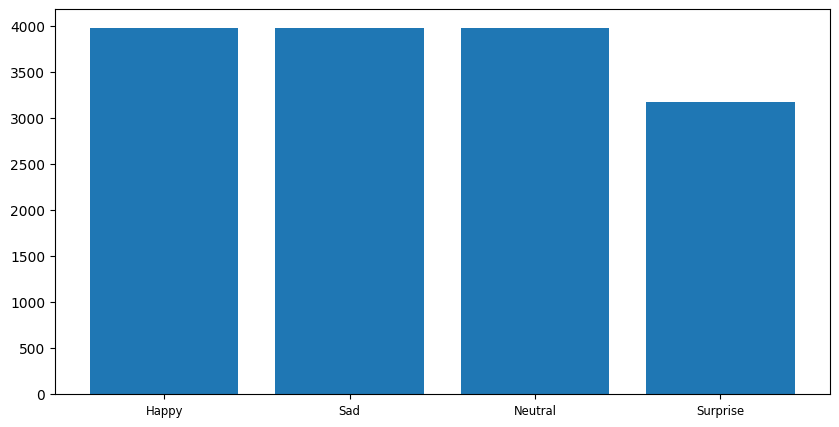

In [ ]:
plt.figure(figsize = (10, 5))

data = {'Happy': num_happy, 'Sad': num_sad, 'Neutral': num_neutral, 'Surprise' : num_surprise}

df = pd.Series(data)

plt.bar(range(len(df)), df.values, align = 'center')

plt.xticks(range(len(df)), df.index.values, size = 'small')

plt.show()

**Observations and Insights:**



*   The classes are not perfectly equally distributed. The 'Surprise' class has noticeably fewer samples compared to the other three classes, which are almost equally distributed.
*   The imbalance is not extreme but is significant enough to potentially affect model performance, especially for the 'Surprise' class. Models trained on imbalanced datasets may develop a bias towards the more frequently represented classes. This can result in poorer generalization performance, particularly for the underrepresented class.
*   Performing EDA can provide deeper insights into the data and help in better understanding the distribution and characteristics of each class.





**Think About It:**
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?
* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [5]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)


datagen_validation = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

validation_set = datagen_validation.flow_from_directory(folder_path + "validation",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)


datagen_test = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?
* What are the advantages of CNNs over ANNs and are they applicable here?

### **Creating the Base Neural Network**

For the task of facial emotional analysis, Convolutional Neural Networks (CNNs) are generally more suitable than traditional Artificial Neural Networks (ANNs).

**1. Nature of Input Data**
CNNs: They are specifically designed to process data that comes in the form of multiple arrays (e.g., image data with channels for red, green, and blue). CNNs are adept at handling the spatial hierarchy in images through their convolutional layers that apply filters to capture patterns like edges, shapes, and textures.
ANNs: Traditional ANNs do not inherently process spatial hierarchies or correlations between adjacent inputs. They treat input data as a flat vector, which means spatial relationships within the data (important in image processing) are lost.
**2. Feature Extraction**
CNNs: Automatically detect important features without any need for manual extraction. Their architecture is very effective in progressively learning higher-level features (e.g., from simple edges to complex objects like facial expressions).
ANNs: Require manual feature extraction and selection. For complex image data, determining and extracting these features can be highly challenging and inefficient.

**3. Parameter Efficiency**
CNNs: Use shared weights in convolutional filters, significantly reducing the number of parameters compared to ANNs. This makes CNNs less prone to overfitting, especially on image data.
ANNs: Have separate parameters for each input feature in each layer, leading to a high number of parameters. This can make ANNs prone to overfitting, especially when the amount of training data is not sufficiently large.

**4. Scalability to Large Images**
CNNs: More scalable for larger images due to their ability to pool features and reduce dimensionality, maintaining the effectiveness even as image resolution increases.
ANNs: Scalability is a challenge as the input size increases, the number of weights grows exponentially, making the network computationally expensive.

**Applicability to Facial Emotional Analysis**

**Localized Feature Learning:** CNNs can learn to recognize specific features in an image, such as parts of a face (eyes, mouth, eyebrows) that are crucial for determining emotions. This localized learning is less efficient in ANNs.

**Robustness to Variations:** CNNs can handle variations in image quality, lighting, and facial positions better due to their convolutional nature, which is essential when analyzing emotions from different individuals and under varying conditions.

Fix the seed for random number generators

In [ ]:
np.random.seed(42)

import random

random.seed(42)

tf.random.set_seed(42)

# Model Architecture


In [ ]:
# Define the model

def cnn_model_1():

    model = Sequential()

    # Adding the first convolutional layer with 64 filters and the kernel size of 3x3
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", activation='relu', input_shape = (48, 48, 1)))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.2))

    # Adding the second convolutional layer with 32 filters and the kernel size of 3x3
    model.add(Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation='relu'))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.2))

    # Adding the third convolutional layer with 32 filters and the kernel size of 3x3
    model.add(Conv2D(filters = 32, kernel_size = (3, 3), padding = 'same', activation='relu'))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.2))

    # Flattening the 3-d output of the convolutional layer after max pooling to make it ready for creating dense connections
    model.add(Flatten())

    # Adding a fully connected dense layer with 512 neurons
    model.add(Dense(512, activation='relu'))

    model.add(Dropout(0.4))

    # Adding the output layer with 4 neurons and 'softmax' activation function (for a multi-class classification problem)
    model.add(Dense(4, activation = 'softmax'))

    # Compile the model with categorical crossentropy loss, Adam optimizer, and accuracy metric
    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])

    return model

In [ ]:
cnn_model_1 = cnn_model_1()

In [ ]:
cnn_model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 48, 48, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 24, 24, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 12, 12, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 12, 12, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 620,740 (2.37 MB)

 Trainable params: 620,740 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

### **Compiling and Training the Model**

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./model1.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

num_epochs = 20

cnn_model_1_history=cnn_model_1.fit(train_set,
                                    validation_data = validation_set,
                                    epochs = num_epochs,
                                    callbacks=callbacks_list,
                                    verbose = 1)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 104s 215ms/step - accuracy: 0.2995 - loss: 1.3575 - val_accuracy: 0.4738 - val_loss: 1.1842 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 101s 213ms/step - accuracy: 0.4649 - loss: 1.1803 - val_accuracy: 0.5467 - val_loss: 1.0817 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 96s 202ms/step - accuracy: 0.5182 - loss: 1.0914 - val_accuracy: 0.5740 - val_loss: 1.0050 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 93s 196ms/step - accuracy: 0.5538 - loss: 1.0327 - val_accuracy: 0.5863 - val_loss: 1.0010 - learning_rate: 0.0010
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 99s 210ms/step - accuracy: 0.5700 - loss: 0.9938 - val_accuracy: 0.6251 - val_loss: 0.9009 - learning_rate: 0.0010
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 100s 212ms/step - accuracy: 0.5793 - loss: 0.9713 - val_accuracy: 0.6251 - val_loss: 0.8796 - learning_rate: 0.0010
Epoch 7/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 102s 216ms/step - accuracy:

### **Evaluating the Model on the Test Set**

In [ ]:
test_loss, test_accuracy = cnn_model_1.evaluate(test_set, verbose=1)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.7500 - loss: 0.5275

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6854 - loss: 0.6799


**Observations and Insights:**



*   Model is performing poor with accuracy of 67%.
*   Trained model with RGB and GRAYSCALE, really no difference. Although all the images were grayscale.



### **Creating the second Convolutional Neural Network**

- Try out a slightly larger architecture

In [6]:
# Clearing backend

from tensorflow.keras import backend

backend.clear_session()

In [7]:
np.random.seed(42)

import random

random.seed(42)

tf.random.set_seed(42)

In [8]:
# Define the model

def cnn_model_2():

    model = Sequential()

    # Adding the first convolutional layer
    model.add(Conv2D(filters = 256, kernel_size = (3, 3), padding = "same", activation='relu', input_shape = (48, 48, 1)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.1))
    model.add(MaxPooling2D(pool_size = (2, 2)))

    # Adding the second convolutional layer
    model.add(Conv2D(filters = 128, kernel_size = (3, 3), padding = "same", activation='relu'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.1))
    model.add(MaxPooling2D(pool_size = (2, 2)))

    # Adding the third convolutional layer
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", activation='relu'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.1))
    model.add(MaxPooling2D(pool_size = (2, 2)))

    # Adding the fourth convolutional layer
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", activation='relu'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.1))
    model.add(MaxPooling2D(pool_size = (2, 2)))

    # Flattening the 3-d output of the convolutional layer after max pooling to make it ready for creating dense connections
    model.add(Flatten())

    # Adding a fully connected dense layer with 512 neurons
    model.add(Dense(512, activation='relu'))

    # Adding a fully connected dense layer with 128 neurons
    model.add(Dense(128, activation='relu'))

    # Adding the output layer with 4 neurons and 'softmax' activation function (for a multi-class classification problem)
    model.add(Dense(4, activation = 'softmax'))

    # Compile the model with categorical crossentropy loss, Adam optimizer, and accuracy metric
    model.compile(loss='categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics=['accuracy'])

    return model

In [9]:
cnn_model_2 = cnn_model_2()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn_model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 256)         │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 48, 48, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 128)         │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 6, 6, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 6, 6, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 3, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         295,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 771,972 (2.94 MB)

 Trainable params: 770,948 (2.94 MB)

 Non-trainable params: 1,024 (4.00 KB)

### **Compiling and Training the Model**

In [11]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./model2.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

num_epochs = 20

cnn_model_2_history=cnn_model_2.fit(train_set,
                                    validation_data = validation_set,
                                    epochs = num_epochs,
                                    callbacks=callbacks_list,
                                    verbose = 1)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 840s 2s/step - accuracy: 0.3469 - loss: 1.3982 - val_accuracy: 0.4233 - val_loss: 1.2924 - learning_rate: 0.0010
Epoch 2/20


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_acc available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


473/473 ━━━━━━━━━━━━━━━━━━━━ 829s 2s/step - accuracy: 0.4809 - loss: 1.1399 - val_accuracy: 0.4886 - val_loss: 1.1510 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 853s 2s/step - accuracy: 0.5728 - loss: 0.9726 - val_accuracy: 0.4961 - val_loss: 1.1461 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 850s 2s/step - accuracy: 0.6208 - loss: 0.8921 - val_accuracy: 0.5859 - val_loss: 0.9591 - learning_rate: 0.0010
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 806s 2s/step - accuracy: 0.6520 - loss: 0.8254 - val_accuracy: 0.6498 - val_loss: 0.8292 - learning_rate: 0.0010
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 837s 2s/step - accuracy: 0.6778 - loss: 0.7552 - val_accuracy: 0.6134 - val_loss: 0.9338 - learning_rate: 0.0010
Epoch 7/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 844s 2s/step - accuracy: 0.6896 - loss: 0.7311 - val_accuracy: 0.6560 - val_loss: 0.8239 - learning_rate: 0.0010
Epoch 8/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 842s 2s/step - accuracy: 0.7012 - loss: 0.7160 - val_

### **Evaluating the Model on the Test Set**

In [12]:
test_loss, test_accuracy = cnn_model_2.evaluate(test_set, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 622ms/step - accuracy: 0.7167 - loss: 0.7536


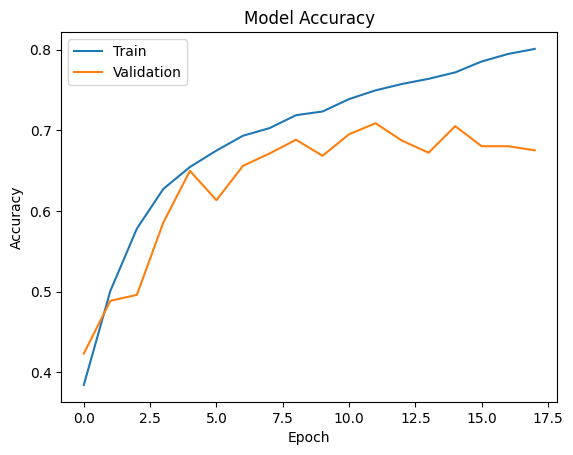

In [14]:
# Plotting the accuracies

plt.plot(cnn_model_2_history.history['accuracy'])

plt.plot(cnn_model_2_history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc = 'upper left')

# Display the plot
plt.show()

**Observations and Insights:**



*   Model has done well on training data achieving 80% accuracy but poorly on validation and test data.
*   Initially model has a good start with training and validation accuracies as seen in above graph but later there was a gap of poor performance.
*   Model is over-fitting due to less regularization ( dropouts), complex data and less data on class (surprise).
*   Also there was no difference using rgb or grayscale as accuracies was almost intact.





## **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?
* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

In [66]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)


datagen_validation = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

validation_set = datagen_validation.flow_from_directory(folder_path + "validation",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)


datagen_test = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [70]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import Model

vgg = VGG16(include_top = False, weights = 'imagenet', input_shape = (48, 48, 3))
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 48, 48, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 48, 48, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 48, 48, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 24, 24, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 1, 1, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [80]:
transfer_layer = vgg.get_layer('block5_pool')
vgg.trainable = False

x = vgg.output
x = Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", activation='relu')(x)
x = MaxPooling2D((2, 2), padding = "same")(x)
x = Dropout(0.2)(x)

x = Conv2D(filters = 32, kernel_size = (3, 3), padding = "same", activation='relu')(x)
x = MaxPooling2D((2, 2), padding = "same")(x)
x = Dropout(0.2)(x)

x = Conv2D(filters = 32, kernel_size = (3, 3), padding = "same", activation='relu')(x)
x = MaxPooling2D((2, 2), padding = "same")(x)
x = Dropout(0.2)(x)

# Flattenning the output from the 3rd block of the VGG16 model
x = Flatten()(x)

# Adding a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
x = Dense(256, activation = 'relu')(x)

# Add a DropOut layer with Drop out ratio of 0.3
x = Dropout(0.3)(x)

# Add a Dense Layer with 64 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Batch Normalization layer
x = BatchNormalization()(x)

# Adding the final dense layer with 4 neurons and use 'softmax' activation
pred = Dense(4, activation='softmax')(x)

vggmodel = Model(vgg.input, pred) # Initializing the model

#Compiling the model
vggmodel.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  # Change loss function based on your problem
              metrics=['accuracy'])

### **Compiling and Training the VGG16 Model**

In [81]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./vggmodel.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

num_epochs = 20

vggmodel_history=vggmodel.fit(train_set,
                                    validation_data = validation_set,
                                    epochs = num_epochs,
                                    callbacks=callbacks_list,
                                    verbose = 1)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3196 - loss: 1.3365
Epoch 1: val_accuracy improved from -inf to 0.39803, saving model to ./vggmodel.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 43s 74ms/step - accuracy: 0.3196 - loss: 1.3364 - val_accuracy: 0.3980 - val_loss: 1.3161 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3796 - loss: 1.2714
Epoch 2: val_accuracy improved from 0.39803 to 0.43219, saving model to ./vggmodel.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - accuracy: 0.3796 - loss: 1.2714 - val_accuracy: 0.4322 - val_loss: 1.2433 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4047 - loss: 1.2525
Epoch 3: val_accuracy improved from 0.43219 to 0.44746, saving model to ./vggmodel.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.4047 - loss: 1.2525 - val_accuracy: 0.4475 - val_loss: 1.2070 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4197 - loss: 1.2317
Epoch 4: val_accuracy did not improve from 0.44746
473/473 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.4197 - loss: 1.2317 - val_accuracy: 0.4111 - val_loss: 1.2241 - learning_rate: 0.0010
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4331 - loss: 1.2216
Epoch 5: val_accuracy improved from 0.44746 to 0.46072, saving model to ./vggmodel.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.4331 - loss: 1.2216 - val_accuracy: 0.4607 - val_loss: 1.1935 - learning_rate: 0.0010
Epoch 6/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4446 - loss: 1.2035
Epoch 6: val_accuracy did not improve from 0.46072
473/473 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.4446 - loss: 1.2036 - val_accuracy: 0.4545 - val_loss: 1.1872 - learning_rate: 0.0010
Epoch 7/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4427 - loss: 1.2123
Epoch 7: val_accuracy did not improve from 0.46072
473/473 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.4427 - loss: 1.2122 - val_accuracy: 0.4366 - val_loss: 1.2124 - learning_rate: 0.0010
Epoch 8/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4500 - loss: 1.1895
Epoch 8: val_accuracy improved from 0.46072 to 0.47016, saving model to ./vggmodel.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.4500 - loss: 1.1895 - val_accuracy: 0.4702 - val_loss: 1.1634 - learning_rate: 0.0010
Epoch 9/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4616 - loss: 1.1904
Epoch 9: val_accuracy did not improve from 0.47016
473/473 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.4616 - loss: 1.1904 - val_accuracy: 0.4549 - val_loss: 1.1837 - learning_rate: 0.0010
Epoch 10/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4646 - loss: 1.1888
Epoch 10: val_accuracy did not improve from 0.47016
473/473 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.4646 - loss: 1.1888 - val_accuracy: 0.4428 - val_loss: 1.1922 - learning_rate: 0.0010
Epoch 11/20
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4566 - loss: 1.1846
Epoch 11: val_accuracy did not improve from 0.47016

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
473/473 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.4567 - loss: 1.18

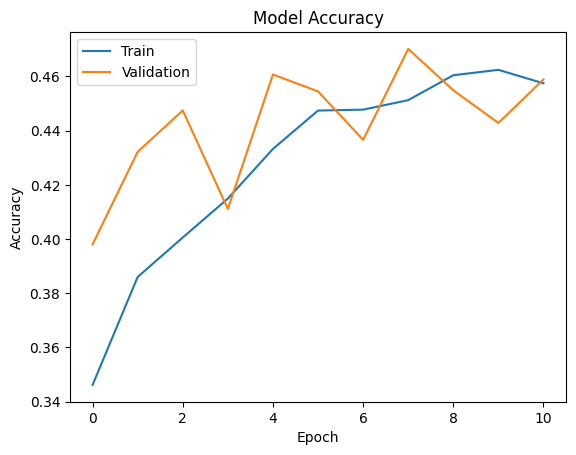

In [82]:
# Plotting the accuracies

plt.plot(vggmodel_history.history['accuracy'])

plt.plot(vggmodel_history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc = 'upper left')

# Display the plot
plt.show()

### **Evaluating the VGG16 model**

In [83]:
test_loss, test_accuracy = vggmodel.evaluate(test_set, verbose=1)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3438 - loss: 1.3079

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4240 - loss: 1.2323


**Think About It:**

- What do you infer from the general trend in the training performance?
- Is the training accuracy consistently improving?
- Is the validation accuracy also improving similarly?

**Observations and Insights**



*   Model has poorly performed with 50% accuracy. Although training accuracy was improving.
*   Validation accuracy was improving but after epoch 6 it started decrasing again and model was overfitting.



**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

In [22]:
import tensorflow as tf
import tensorflow.keras.applications as ap
from tensorflow.keras import Model

Resnet = ap.ResNet101(include_top = False, weights = "imagenet", input_shape=(48,48,3))
Resnet.summary()

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "resnet101"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 48, 48, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 54, 54, 3)      │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 24, 24, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 24, 24, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 24, 24, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 26, 26, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 12, 12, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 12, 12, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 12, 12, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 12, 12, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 12, 12, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 12, 12, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 12, 12, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 12, 12, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 12, 12, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 42,658,176 (162.73 MB)

 Trainable params: 42,552,832 (162.33 MB)

 Non-trainable params: 105,344 (411.50 KB)

### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [23]:
transfer_layer_Resnet = Resnet.get_layer('conv5_block3_add')
Resnet.trainable=False

# Flattenning the output from the 3rd block
x = Flatten()(transfer_layer_Resnet.output)

# Add a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
x = Dense(128, activation = 'relu')(x)

# Add a DropOut layer with Drop out ratio of 0.3
x = Dropout(0.3)(x)

# Add a Dense Layer with 64 neurons
x = Dense(64, activation = 'relu')(x)

# Add a Batch Normalization layer
x = BatchNormalization()(x)

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation = 'softmax')(x)

resnetmodel = Model(Resnet.input, pred) # Initializing the model

#Compiling the model
resnetmodel.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  # Change loss function based on your problem
              metrics=['accuracy'])

### **Compiling and Training the Model**

In [24]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./resnetmodel.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

num_epochs = 20

resnetmodel_history=resnetmodel.fit(train_set,
                                    validation_data = validation_set,
                                    epochs = num_epochs,
                                    callbacks=callbacks_list,
                                    verbose = 1)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 395s 793ms/step - accuracy: 0.2493 - loss: 1.5595 - val_accuracy: 0.2443 - val_loss: 1.3692 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 369s 781ms/step - accuracy: 0.2499 - loss: 1.4139 - val_accuracy: 0.3667 - val_loss: 1.3575 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 423s 895ms/step - accuracy: 0.2633 - loss: 1.3962 - val_accuracy: 0.2443 - val_loss: 1.3625 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 387s 780ms/step - accuracy: 0.2519 - loss: 1.3952 - val_accuracy: 0.3667 - val_loss: 1.3477 - learning_rate: 0.0010
Epoch 5/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 376s 795ms/step - accuracy: 0.2598 - loss: 1.3899 - val_accuracy: 0.3667 - val_loss: 1.3544 - learning_rate: 0.0010
Epoch 6/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 375s 780ms/step - accuracy: 0.2600 - loss: 1.3903 - val_accuracy: 0.3667 - val_loss: 1.3706 - learning_rate: 0.0010
Epoch 7/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy

### **Evaluating the ResNet Model**

In [25]:
test_loss, test_accuracy = resnetmodel.evaluate(test_set, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step - accuracy: 0.2729 - loss: 1.3930


**Observations and Insights:**


*   Model has a poor performance with 26% training and 36% validation accuracy,
*   RestNet model may be too deep that lead to poor performance.



**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

## **EfficientNet Model**

In [26]:
import tensorflow as tf
import tensorflow.keras.applications as ap
from tensorflow.keras import Model

EfficientNet = ap.EfficientNetV2B2(include_top=False,weights="imagenet", input_shape= (48, 48, 3))

EfficientNet.summary()

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetv2-b2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 48, 48, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 48, 48, 3)      │              0 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 48, 48, 3)      │              0 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 24, 24, 32)     │            864 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 24, 24, 32)     │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 24, 24, 32)     │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_conv      │ (None, 24, 24, 16)     │          4,608 │ stem_activation[0][0]  │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_bn        │ (None, 24, 24, 16)     │             64 │ block1a_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_project_activati… │ (None, 24, 24, 16)     │              0 │ block1a_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_conv      │ (None, 24, 24, 16)     │          2,304 │ block1a_project_activ… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_bn        │ (None, 24, 24, 16)     │             64 │ block1b_project_conv[… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_project_activati… │ (None, 24, 24, 16)     │              0 │ block1b_project_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_drop (Dropout)    │ (None, 24, 24, 16)     │              0 │ block1b_project_activ… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1b_add (Add)         │ (None, 24, 24, 16)     │              0 │ block1b_drop[0][0],    │
│                           │                        │                │ block1a_project_activ… │
├──────────────────────

 Total params: 8,769,374 (33.45 MB)

 Trainable params: 8,687,086 (33.14 MB)

 Non-trainable params: 82,288 (321.44 KB)

### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [27]:
transfer_layer_EfficientNet = EfficientNet.get_layer('block6e_expand_activation')
EfficientNet.trainable = False

# Flattenning the output
x = Flatten()(transfer_layer_EfficientNet.output)

# Add a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)

# Add a Dense Layer with 128 neurons
x = Dense(128, activation = 'relu')(x)

# Add a DropOut layer with Drop out ratio of 0.3
x = Dropout(0.3)(x)

# Add a Dense Layer with 64 neurons
x = Dense(64, activation = 'relu')(x)

# Add a Batch Normalization layer
x = BatchNormalization()(x)

# Add the final dense layer with 4 neurons and use a 'softmax' activation
pred = Dense(4, activation = 'softmax')(x)

Efficientnetmodel = Model(EfficientNet.input, pred)

#Compiling the model
Efficientnetmodel.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  # Change loss function based on your problem
              metrics=['accuracy'])

### **Compiling and Training the Model**

In [28]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./Efficientnetmodel.h5", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

num_epochs = 20

Efficientnetmodel_history=Efficientnetmodel.fit(train_set,
                                    validation_data = validation_set,
                                    epochs = num_epochs,
                                    callbacks=callbacks_list,
                                    verbose = 1)

Epoch 1/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 187s 353ms/step - accuracy: 0.2493 - loss: 1.5056 - val_accuracy: 0.3667 - val_loss: 1.3575 - learning_rate: 0.0010
Epoch 2/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 170s 286ms/step - accuracy: 0.2608 - loss: 1.4067 - val_accuracy: 0.2289 - val_loss: 1.3934 - learning_rate: 0.0010
Epoch 3/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 125s 264ms/step - accuracy: 0.2592 - loss: 1.3967 - val_accuracy: 0.2289 - val_loss: 1.4083 - learning_rate: 0.0010
Epoch 4/20
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.2669 - loss: 1.3936
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
473/473 ━━━━━━━━━━━━━━━━━━━━ 142s 265ms/step - accuracy: 0.2669 - loss: 1.3936 - val_accuracy: 0.2289 - val_loss: 1.3673 - learning_rate: 0.0010
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


### **Evaluating the EfficientnetNet Model**

In [29]:
test_loss, test_accuracy = Efficientnetmodel.evaluate(test_set, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.2500 - loss: 1.4003


**Observations and Insights:**



*   Same issue of poor performance.
*   the pre-trained weights might not align well with the specific nuances of facial emotion recognition.


**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
* Do you think our issue lies with 'rgb' color_mode?



*   All transfer learning models has poor performance with low accuracies. Only VGG16 achieved better accuracy of 50% on training data set.
*   I don't believe issues lies with RGB selection in dataset



Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

In [56]:
# Clearing backend

from tensorflow.keras import backend

backend.clear_session()

In [57]:
# Fixing the seed for random number generators

np.random.seed(42)

import random

random.seed(42)

tf.random.set_seed(42)

In [58]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)


datagen_validation = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

validation_set = datagen_validation.flow_from_directory(folder_path + "validation",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)


datagen_test = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                              target_size = (img_size, img_size),
                                              color_mode = 'grayscale',
                                              batch_size = batch_size,
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              class_mode = 'categorical',
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

In [59]:
# Define the model
def cnn_model_3():

    model = Sequential()

    # Adding the first convolutional layer
    model.add(Conv2D(filters = 64, kernel_size = (3, 3), padding = "same", input_shape = (48, 48, 1)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.1))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.1))

    # Adding the second convolutional layer
    model.add(Conv2D(filters = 128, kernel_size = (3, 3), padding = "same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.1))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.15))

    # Adding the third convolutional layer
    model.add(Conv2D(filters = 512, kernel_size = (3, 3), padding = "same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.1))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.2))

    # Adding the fourth convolutional layer
    model.add(Conv2D(filters = 512, kernel_size = (3, 3), padding = "same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.1))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.2))

    # Adding the fifth convolutional layer
    model.add(Conv2D(filters = 128, kernel_size = (3, 3), padding = "same"))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.1))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.2))

    # Flattening the 3-d output of the convolutional layer after max pooling to make it ready for creating dense connections
    model.add(Flatten())

    # Adding a fully connected dense layer with 256 neurons
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Adding a fully connected dense layer with 512 neurons
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # Adding the output layer with 4 neurons and 'softmax' activation function (for a multi-class classification problem)
    model.add(Dense(4, activation = 'softmax'))

    #Compiling the model
    model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  # Change loss function based on your problem
              metrics=['accuracy'])

    return model

In [60]:
cnn_model_3 = cnn_model_3()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
cnn_model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 512)         │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 12, 12, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 6, 6, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 3,789,700 (14.46 MB)

 Trainable params: 3,785,476 (14.44 MB)

 Non-trainable params: 4,224 (16.50 KB)

### **Compiling and Training the Model**

In [62]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./cnn_model3.h5", monitor = 'val_accuracy',
                            save_best_only = True, mode = 'max', verbose = 1)

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.1, patience = 2, min_lr = 0.0001 , model = 'auto')

callbacks_list = [checkpoint, reduce_learningrate]

num_epochs = 30

cnn_model_3_history=cnn_model_3.fit(train_set,
                                    validation_data = validation_set,
                                    epochs = num_epochs,
                                    callbacks=callbacks_list,
                                    verbose = 1)

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2617 - loss: 1.7985
Epoch 1: val_accuracy improved from -inf to 0.36207, saving model to ./cnn_model3.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.2617 - loss: 1.7979 - val_accuracy: 0.3621 - val_loss: 1.3660 - learning_rate: 0.0010
Epoch 2/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3009 - loss: 1.4256
Epoch 2: val_accuracy did not improve from 0.36207
473/473 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.3010 - loss: 1.4255 - val_accuracy: 0.3476 - val_loss: 1.3324 - learning_rate: 0.0010
Epoch 3/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4715 - loss: 1.1742
Epoch 3: val_accuracy improved from 0.36207 to 0.55736, saving model to ./cnn_model3.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.4716 - loss: 1.1741 - val_accuracy: 0.5574 - val_loss: 1.0472 - learning_rate: 0.0010
Epoch 4/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5450 - loss: 1.0408
Epoch 4: val_accuracy improved from 0.55736 to 0.57565, saving model to ./cnn_model3.h5


...

473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.7676 - loss: 0.5680 - val_accuracy: 0.7452 - val_loss: 0.6525 - learning_rate: 1.0000e-04
Epoch 19/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7750 - loss: 0.5592
Epoch 19: val_accuracy did not improve from 0.74523
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.7750 - loss: 0.5592 - val_accuracy: 0.7428 - val_loss: 0.6681 - learning_rate: 1.0000e-04
Epoch 20/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7863 - loss: 0.5452
Epoch 20: val_accuracy did not improve from 0.74523
473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.7862 - loss: 0.5452 - val_accuracy: 0.7432 - val_loss: 0.6573 - learning_rate: 1.0000e-04
Epoch 21/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7845 - loss: 0.5412
Epoch 21: val_accuracy did not improve from 0.74523
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.7845 - loss: 0.5412 - val_accuracy: 0.7444 - val_loss: 0.6777 - learning_rate: 1.0

473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.7957 - loss: 0.5252 - val_accuracy: 0.7456 - val_loss: 0.6634 - learning_rate: 1.0000e-04
Epoch 23/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7867 - loss: 0.5251
Epoch 23: val_accuracy improved from 0.74563 to 0.75025, saving model to ./cnn_model3.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.7867 - loss: 0.5251 - val_accuracy: 0.7503 - val_loss: 0.6622 - learning_rate: 1.0000e-04
Epoch 24/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7983 - loss: 0.5170
Epoch 24: val_accuracy did not improve from 0.75025
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.7983 - loss: 0.5170 - val_accuracy: 0.7440 - val_loss: 0.6688 - learning_rate: 1.0000e-04
Epoch 25/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8028 - loss: 0.5071
Epoch 25: val_accuracy did not improve from 0.75025
473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8027 - loss: 0.5071 - val_accuracy: 0.7474 - val_loss: 0.6508 - learning_rate: 1.0000e-04
Epoch 26/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8071 - loss: 0.4910
Epoch 26: val_accuracy improved from 0.75025 to 0.75146, saving model to ./cnn_model3.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.8071 - loss: 0.4910 - val_accuracy: 0.7515 - val_loss: 0.6563 - learning_rate: 1.0000e-04
Epoch 27/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8062 - loss: 0.4947
Epoch 27: val_accuracy did not improve from 0.75146
473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8062 - loss: 0.4947 - val_accuracy: 0.7480 - val_loss: 0.6664 - learning_rate: 1.0000e-04
Epoch 28/30
473/473 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8118 - loss: 0.4846
Epoch 28: val_accuracy did not improve from 0.75146
473/473 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.8118 - loss: 0.4846 - val_accuracy: 0.7456 - val_loss: 0.6727 - learning_rate: 1.0000e-04
Epoch 29/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8123 - loss: 0.4720
Epoch 29: val_accuracy improved from 0.75146 to 0.75266, saving model to ./cnn_model3.h5


473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8123 - loss: 0.4720 - val_accuracy: 0.7527 - val_loss: 0.6753 - learning_rate: 1.0000e-04
Epoch 30/30
472/473 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8170 - loss: 0.4582
Epoch 30: val_accuracy did not improve from 0.75266
473/473 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.8170 - loss: 0.4583 - val_accuracy: 0.7414 - val_loss: 0.7010 - learning_rate: 1.0000e-04


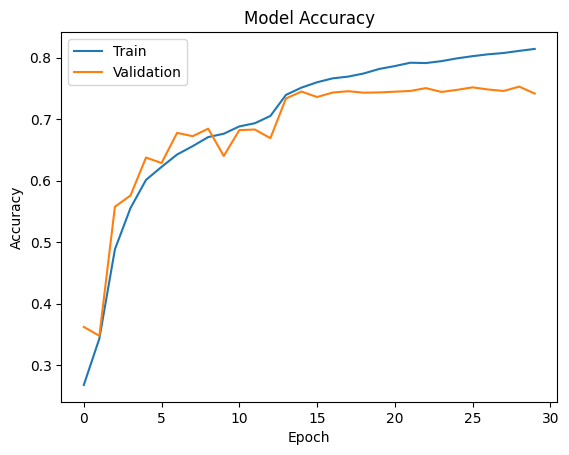

In [63]:
plt.plot(cnn_model_3_history.history['accuracy'])

plt.plot(cnn_model_3_history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'], loc = 'upper left')

# Display the plot
plt.show()

### **Evaluating the Model on Test Set**

In [64]:
test_loss, test_accuracy = cnn_model_3.evaluate(test_set, verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7635 - loss: 0.6381


**Observations and Insights:__**

### **Plotting the Confusion Matrix for the chosen final model**

Found 128 images belonging to 4 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step 


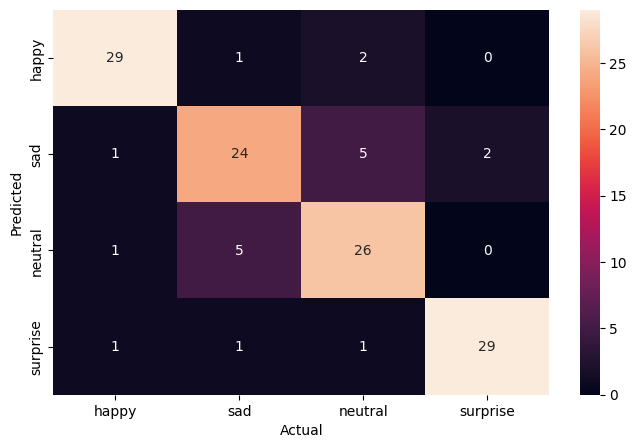

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        32
           1       0.77      0.75      0.76        32
           2       0.76      0.81      0.79        32
           3       0.94      0.91      0.92        32

    accuracy                           0.84       128
   macro avg       0.85      0.84      0.84       128
weighted avg       0.85      0.84      0.84       128



In [65]:
# Plot the confusion matrix and generate a classification report for the model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                                              target_size = (img_size,img_size),
                                                              color_mode = 'grayscale',
                                                              batch_size = 128,
                                                              class_mode = 'categorical',
                                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                                              shuffle = True)

test_images, test_labels = next(test_set)

# Write the name of your chosen model in the blank
Y_pred = cnn_model_3.predict(test_images)
Y_pred = np.argmax(Y_pred, axis = 1)
Y_test = np.argmax(test_labels, axis = 1)

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['happy', 'sad', 'neutral', 'surprise'], yticklabels = ['happy', 'sad', 'neutral', 'surprise'])
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.show()

# Print the metrics
print(classification_report(Y_test, Y_pred))

**Observations and Insights:**



*   Model performed well with 80% accuracy on training set and 75% accuracy on vaidation set
*   On test set it performed with achieving accuracy of 76%
*   Also it is evident from confusion matrix that most of the predictions were correct for surprise and happy classes.
*   There wer some wrong predictions where sad and neutral predicted. It is becasue of some similarities between those 2 facial expressions.


*   Overall accuracy is 84% which is good.
*   Precision and Recall is comparatively lower for class 1 (sad)







## **Conclusion:____________**

### **Insights**

### **Refined insights**:
# What are the most meaningful insights from the data relevant to the problem?


  *   The dataset contains a wide range of facial expressions, crucial for training a model to recognize different emotions.
  *   Images are in grayscale and of moderate resolution, which might affect the model’s ability to capture very fine details.
  * Some images show faces partially occluded (e.g., by hands), which is useful for training the model to handle real-world scenarios where occlusions might occur.
  * The dataset includes individuals from various ethnic backgrounds, enhancing the model's ability to generalize across different demographics.
  * Although "Surprise" have less samples than others but didn't ran into class imbalance.





### **Comparison of various techniques and their relative performance**:
**- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?**

Custom CNN ( cnn_model_3 ): This architecture has outperformed the others, indicating that a simpler, more tailored model can sometimes be more effective for specific datasets, particularly when the data does not require extremely deep architectures to capture relevant features.
VGG16, ResNetV2, and EfficientNet: These pre-trained models have shown lower accuracies. This could be due to overfitting, as these models are complex and designed for much larger and more varied datasets (like ImageNet).

Custom CNN (cnn_model_3) performed better relative to VGG16, ResNetV2, and EfficientNet in this specific application of facial emotional analysis. This suggests that the features required to perform well on your dataset are sufficiently captured by the simpler architecture of the custom CNN, without needing the depth and complexity of the larger models.

### **Proposal for the final solution design**:
**- What model do you propose to be adopted? Why is this the best solution to adopt?**

Based on the performance evaluations and the specific requirements of  facial emotional analysis task, I recommend adopting the Custom CNN model (cnn_model_3 ). Here’s why this model is the best solution to adopt:

1. Tailored Architecture:
The Custom CNN has been specifically designed and optimized for our dataset, which likely means it has the right complexity to capture the necessary features without overfitting. This is particularly important given that the dataset might not be as large or as varied as those typically used with pre-trained models like VGG16, ResNet, or EfficientNet.
2. Better Performance:
The Custom CNN has already demonstrated superior performance compared to the pre-trained models. This suggests that the features it is learning are more relevant and useful for the specific task of facial emotional analysis in our context.
3. Efficiency:
Custom CNNs are generally more computationally efficient compared to deeper, more complex models. This efficiency makes the model faster to train and infer, which is beneficial for practical deployment, especially if the model needs to be run on devices with limited computational resources.
4. Flexibility and Scalability:
With a custom architecture, I have the flexibility to modify and scale the model as needed based on ongoing performance assessments and potentially evolving dataset characteristics. This adaptability is crucial as it allows the model to evolve in line with new data or changing requirements.
5. Reduced Risk of Overfitting:
The simpler architecture relative to deep pre-trained networks reduces the risk of overfitting, which is a common issue when using complex models on datasets that do not have the immense variety and volume of data like ImageNet.
6. Opportunity for Further Optimization:
There is still scope to experiment with and optimize the Custom CNN further through techniques such as hyperparameter tuning, advanced regularization, and enhanced data augmentation. This potential for optimization can lead to even better performance as more insights are gained from ongoing training and deployment.
